In [1]:
import numpy as np
import math

from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator


# Gray-Synth
Following the pseudocode of Algorithm 1 from "arXiv:1712.01859", I implement a function to build the circuit of the parity network given a set of binary strings.

In [2]:
def gray_synth(S_all, verbose=False, build_cicuit=False):
    """
    Input:
        S_all: list of lists representing parity vectors
        verbose: whether to print intermediate steps
        build_circuit: whether to build the circuit

    Output:
        cnot_list: list of tuples (control, target), representing the CNOT to be applied in order
        A_evolution: list of matrices representing the linear transformation of the circuit updated after each CNOT application
    """
    S_all = [list(map(int, y)) for y in S_all]
    n = len(S_all[0])
    cnot_list = []
    if build_cicuit: C = QuantumCircuit(n)

    Q = []
    Q.append((S_all, list(range(n)), None))
    
    # List of matrix A_i to keep track of the linear transformations (used to insert phase gates)
    A_evolution = []
    A_evolution.append(np.identity(n, dtype=np.uint8))

    while len(Q) != 0:
        S, I, i = Q.pop()

        if verbose:
            print("=" * 100)
            print(f"S = {S}")
            print(f"I = {I}")
            print(f"i = {i}\n")

        if len(S) == 0:
            continue

        if i is not None:
            while True:
                found = False

                for j in range(n):
                    if j != i and all(y[j] == 1 for y in S):
                        if build_cicuit: C.cx(control_qubit=j, target_qubit=i)
                        cnot_list.append((j,i))

                        # Update current subset
                        for y in S:
                            y[j] ^= y[i]

                        # Update all subsets already in the stack
                        for S_prime, _, _ in Q:
                            for y in S_prime:
                                y[j] ^= y[i]
                        
                        # Update linear map A_i
                        A = A_evolution[-1].copy()
                        A[i, :] ^= A[j, :]
                        A_evolution.append(A)

                        if verbose: 
                            print(f"Applied CNOT with control {j} and target {i}.")
                            print(f"Current linear transformation A_{len(A_evolution)-1}: \n{A}\n")

                        found = True
                        break

                if not found:
                    break
        
        if len(I) == 0:
            continue
        
        # Select index j
        j = max(I, key=lambda j: max(sum(y[j] == 0 for y in S), sum(y[j] == 1 for y in S)))

        # Create co-factors S_0 and S_1
        S0 = [y for y in S if y[j] == 0]
        S1 = [y for y in S if y[j] == 1]

        # Update index list of the new elements
        I_new = [k for k in I if k != j]

        # Push the tuples fo the new cofactors
        if i is None:
            Q.append((S1, I_new.copy(), j))
        else:
            Q.append((S1, I_new.copy(), i))

        Q.append((S0, I_new.copy(), i))


    if verbose:
        print()
        print("=" * 100)
        print("CNOT applied, represented as (control, target):", cnot_list)
        print("=" * 100)

    if build_cicuit:
        return C, cnot_list, A_evolution
    else:
        return cnot_list, A_evolution

### Example
I implement the parity network of the CCZ gate.

S = [[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 1, 0], [1, 0, 1], [0, 1, 1], [1, 1, 1]]
I = [0, 1, 2]
i = None

S = [[0, 1, 0], [0, 0, 1], [0, 1, 1]]
I = [1, 2]
i = None

S = [[0, 0, 1]]
I = [2]
i = None

S = []
I = []
i = None

S = [[0, 0, 1]]
I = []
i = 2

S = [[0, 1, 0], [0, 1, 1]]
I = [2]
i = 1

S = [[0, 1, 0]]
I = []
i = 1

S = [[0, 1, 1]]
I = []
i = 1

Applied CNOT with control 2 and target 1.
Current linear transformation A_1: 
[[1 0 0]
 [0 1 1]
 [0 0 1]]

S = [[1, 0, 0], [1, 1, 1], [1, 0, 1], [1, 1, 0]]
I = [1, 2]
i = 0

S = [[1, 0, 0], [1, 0, 1]]
I = [2]
i = 0

S = [[1, 0, 0]]
I = []
i = 0

S = [[1, 0, 1]]
I = []
i = 0

Applied CNOT with control 2 and target 0.
Current linear transformation A_2: 
[[1 0 1]
 [0 1 1]
 [0 0 1]]

S = [[1, 1, 0], [1, 1, 1]]
I = [2]
i = 0

Applied CNOT with control 1 and target 0.
Current linear transformation A_3: 
[[1 1 0]
 [0 1 1]
 [0 0 1]]

S = [[1, 0, 0]]
I = []
i = 0

S = [[1, 0, 1]]
I = []
i = 0

Applied CNOT with control 2 and target 0.
Current lin

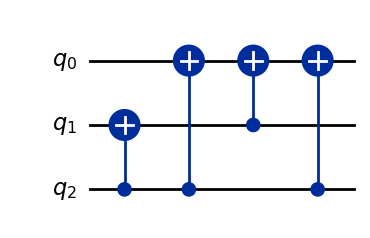

In [3]:
# Set of binary strings needed to build the CCZ
S_ccz = [[1,0,0], 
         [0,1,0],
         [0,0,1],
         [1,1,0],
         [1,0,1],
         [0,1,1],
         [1,1,1]]


# Number of qubits used
n = len(S_ccz[0])

# Build block of the circuit implementing the parity network
qc_parity, cnot_list, A_evolution = gray_synth(S_ccz, verbose=True, build_cicuit=True)
qc_parity.draw("mpl")

# Patel-Markov-Hayes Algorithm
Following the asymptotically optimal algorithm proposed in "arXiv:quant-ph/0302002", I create a function which decomposes a linear binary matrix, $A$, into matrices performing elementary row addition. These matrices correspond to CNOT gates.

This function is used to decompose the final linear transformation applied by the parity network. Since CNOT is Hermitian, applying the obtained sequence of CNOT in the reverse order it is possible to apply $A^{-1}$ and revert the transformation.

In [4]:
def lwr_cnot_synth(A, m):
    n = A.shape[0]
    A = A.copy() % 2
    circuit: list[tuple[int, int]] = []

    for sec in range(1, math.ceil(n / m) + 1):
        col_start = (sec - 1) * m
        col_end = min(sec * m, n)

        # Step A: eliminate duplicate sub-rows in this section
        patt: dict[tuple, int] = {}
        for row_ind in range(col_start, n):
            sub_row = tuple(A[row_ind, col_start:col_end])
            if all(v == 0 for v in sub_row):
                continue
            if sub_row not in patt:
                patt[sub_row] = row_ind
            else:
                src = patt[sub_row]
                A[row_ind, :] = (A[row_ind, :] + A[src, :]) % 2
                circuit.append((src, row_ind))

        # Steps B & C: Gaussian elimination on the column section
        for col_ind in range(col_start, col_end):
            diag_one = A[col_ind, col_ind] == 1

            for row_ind in range(col_ind + 1, n):
                if A[row_ind, col_ind] == 1:
                    if not diag_one:
                        # Step B: pull a 1 up to the diagonal
                        A[col_ind, :] = (A[col_ind, :] + A[row_ind, :]) % 2
                        circuit.append((row_ind, col_ind))
                        diag_one = True

                    # Step C: zero out the 1 below the diagonal
                    A[row_ind, :] = (A[row_ind, :] + A[col_ind, :]) % 2
                    circuit.append((col_ind, row_ind))

    return A, circuit


def cnot_synth(A, m=None):
    A = np.array(A, dtype=int) % 2
    n = A.shape[0]
    assert A.shape == (n, n), "A must be square."

    if m is None:
        m = max(1, round(math.log2(n) / 2))

    # Reduce A to upper triangular U, collecting circ_l
    U, circ_l = lwr_cnot_synth(A, m)

    # Reduce U^T (lower triangular) to I, collecting circ_u
    _, circ_u = lwr_cnot_synth(U.T.copy(), m)

    u_part = [(t, c) for (c, t) in circ_u]
    l_part = list(reversed(circ_l))

    return u_part + l_part

### Example
I implement the block performing the inverse of the linear transformation of the parity network of the CCZ gate.

To decompose A apply these CNOT, represented as (control, target): [(1, 0), (2, 0), (2, 1)]
To uncompute apply these CNOT, represented as (control, target): [(2, 1), (2, 0), (1, 0)]


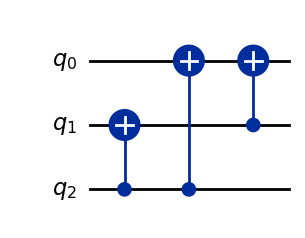

In [17]:
cnot_decomp = cnot_synth(A_evolution[-1])
cnot_uncomp = [cnot_decomp[-i-1] for i, _ in enumerate(cnot_decomp)]
print("To decompose A apply these CNOT, represented as (control, target):", cnot_decomp)
print("To uncompute apply these CNOT, represented as (control, target):", cnot_uncomp)

# Build block of the circuit implementing uncomputing
qc_uncompute = QuantumCircuit(n)
for element in cnot_uncomp:
    qc_uncompute.cx(*element)
qc_uncompute.draw("mpl")

# Circuit Creation
I connect all the pieces and I build a circuit given its sum-over-path form $(f, T)$. 

Given the set of binary strings, $S_{all}$, I build the parity network. Using the matrices representing the linear transformations applied after each CNOT, I find the parity in the circuit and I apply the corresponding Z-basis rotation. I invert the linear transformation applied by the parity network and apply A.

The final circuit corresponds to the unitary: $\sum_{}e^{i2\pi f(x)}|Tx\rangle\langle x|$.

In [7]:
def build_cnot_phase_circuit(S_all, rot_all, T):
    n = len(S_all[0])

    # Create circuit
    qc = QuantumCircuit(n)

    # Build parity network
    cnot_list, A_evolution = gray_synth(S_all)
    S = S_all.copy()

    for t, A in enumerate(A_evolution):
        for i_wire in range(A.shape[0]):
            row = A[i_wire, :]
            i_y = next((i for i, y in enumerate(S) if np.array_equal(row % 2, np.array(y) % 2)), None)

            # Add Z-basis rotation if the parity is found
            if i_y is not None:
                y = S.pop(i_y)
                angle = rot_all[S_all.index(y)]
                qc.rz(2 * np.pi * angle, i_wire)

        # Apply CNOT
        if t != len(A_evolution) - 1:
            qc.cx(*cnot_list[t])

    # Uncompute
    qc.barrier()
    cnot_unc_list = cnot_synth(A_evolution[-1])
    for element in reversed(cnot_unc_list):
        qc.cx(*element)
    
    # Apply the linear transformation T
    qc.barrier()
    cnot_transform = cnot_synth(T % 2)
    for element in reversed(cnot_transform):
        qc.cx(*element)

    return qc


### Example
I build the circuit of the CCZ, given it's sum-over-path form.

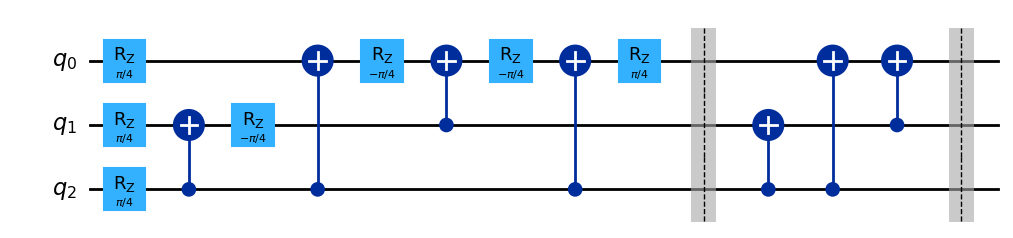

In [12]:
S_ccz = [[1,0,0], 
         [0,1,0],
         [0,0,1],
         [1,1,0],
         [1,0,1],
         [0,1,1],
         [1,1,1]]

rot_ccz = [1/8,
           1/8,
           1/8,
           -1/8,
           -1/8,
           -1/8,
           1/8,]

T_ccz = np.identity(n, dtype=np.uint8)
qc_ccz = build_cnot_phase_circuit(S_ccz, rot_ccz, T_ccz)
qc_ccz.draw("mpl")

I check that the circuit implements the CCZ gate up to a global phase.

In [9]:
def ccz_reference_circuit(n=3, qubits=(0, 1, 2)):
    ref = QuantumCircuit(n)
    ref.ccz(*qubits)
    return ref

def equal_up_to_global_phase(U, V, atol=1e-10):
    U = np.asarray(U, dtype=complex)
    V = np.asarray(V, dtype=complex)

    # W should be scalar times identity if U and V differ only by global phase
    W = U @ V.conj().T

    # Estimate global phase from trace
    phase = np.trace(W) / W.shape[0]

    if np.isclose(abs(phase), 0.0, atol=atol):
        return False, None, W

    phase /= abs(phase)

    is_equal = np.allclose(W, phase * np.eye(W.shape[0]), atol=atol)
    phi = np.angle(phase)

    return is_equal, phi, W

U = Operator(qc_ccz).data

# Ideal CCZ circuit on the same number of qubits
ref = ccz_reference_circuit(qc_ccz.num_qubits, qubits=(0, 1, 2))
V = Operator(ref).data

is_equal, phi, W = equal_up_to_global_phase(U, V)

print("Equal to CCZ up to global phase:", is_equal)
print("Global phase phi:", phi)
print("Max error:", np.max(np.abs(W - np.exp(1j * phi) * np.eye(W.shape[0]))))

Equal to CCZ up to global phase: True
Global phase phi: -0.3926990816987242
Max error: 2.7755575615628914e-16


### Example
I build the circuit of Example 4.2 from "arXiv:1712.01859".

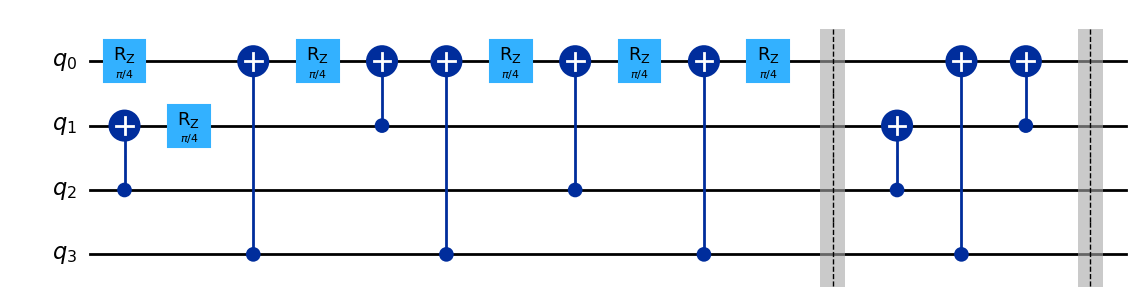

In [11]:
S_ex = [[0,1,1,0], 
         [1,0,0,0],
         [1,0,0,1],
         [1,1,1,0],
         [1,1,0,1],
         [1,1,0,0]]

rot_ex = [1/8]*6

T_ex = np.identity(len(S_ex[0]), dtype=np.uint8)

qc_ex = build_cnot_phase_circuit(S_ex, rot_ex, T_ex)
qc_ex.draw("mpl")